# Diagnóstico de calidad de datos — Adult/Census Income

## Objetivo

Analizar la calidad de los datos crudos, identificar problemas y recopilar evidencia para justificar  las decisiones de validación y limpieza.

**Importante:** No se modificará el archivo con los datos crudos de la carpeta `data/raw/`.

## Carga de los datos

In [1]:
# Importar librerias
from pathlib import Path
import pandas as pd

# Ubicar la carpeta del repositorio y construir la ruta del archivo con los datos crudos
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "adult_raw.csv"

# Cargar los datos en un DataFrame sin modificar el archivo original
df = pd.read_csv(RAW_DATA_PATH)

# Comprobar la carga
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Filas: 48,842
Columnas: 15


## Revisión inicial de los datos

In [2]:
# Primeras 5 filas del df
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
# Tipo de dato de cada columna
df.dtypes

age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object

En esta revisión inicial no se detectó ningún problema, se encuentran todas las variables esperadas y los tipos de datos son correctos.

## Valores faltantes

### Valores faltantes

In [4]:
# Valores faltantes
df.isna().sum().sort_values(ascending=False)

occupation        966
workclass         963
native-country    274
fnlwgt              0
education           0
education-num       0
age                 0
marital-status      0
relationship        0
sex                 0
race                0
capital-gain        0
capital-loss        0
hours-per-week      0
income              0
dtype: int64

### Valores faltantes codificados mediante el símbolo ?

In [5]:
# Columnas de texto
text_columns = df.select_dtypes(include=["object", "string"]).columns

# Contar cuántas veces aparece "?" por columna
question_mark_count = df[text_columns].apply(
    lambda column: column.astype("string").str.strip().eq("?").sum()
)
question_mark_count.sort_values(ascending=False)

occupation        1843
workclass         1836
native-country     583
marital-status       0
education            0
relationship         0
race                 0
sex                  0
income               0
dtype: int64

Se detectaron valores faltantes tanto NaN como ? en las columnas occupation, workclass y native-country.

### Análisis para la decisión de limpieza

Total de datos faltantes

In [6]:
# Copia del df para el diagnostico
df_quality = df.copy()

# Reemplazar únicamente los símbolos "?" por valores faltantes reconocidos
for column in text_columns:
    is_question_mark = (
        df_quality[column]
        .astype("string")
        .str.strip()
        .eq("?")
    )
    df_quality.loc[is_question_mark, column] = pd.NA

# Calcular nuevamente la cantidad y el porcentaje total de faltantes
combined_missing = pd.DataFrame({
    "Cantidad": df_quality.isna().sum(),
    "Porcentaje": (df_quality.isna().mean() * 100).round(2)
})

# Columnas con faltantes
combined_missing[
    combined_missing["Cantidad"] > 0
].sort_values(by="Cantidad", ascending=False)

,Cantidad,Porcentaje
occupation,2809,5.75
workclass,2799,5.73
native-country,857,1.75


En general, los datos faltantes no son una gran proporción del conjunto de datos. Occupation es la variable con la mayor cantidad de datos faltantes (5.75%), seguida de workclass (5.73%) y por último native country (1.75%).

Cantidad de filas afectadas

In [7]:
# Identificar las filas que tienen al menos un valor faltante
rows_with_missing = df_quality.isna().any(axis=1)

# Calcular la cantidad y el porcentaje de filas afectadas
affected_rows_count = rows_with_missing.sum()
affected_rows_percentage = rows_with_missing.mean() * 100

# Mostrar los resultados
print(f"Cantidad de filas afectadas: {affected_rows_count:,}")
print(f"Porcentaje de filas afectadas: {affected_rows_percentage:.2f}%")

Cantidad de filas afectadas: 3,620
Porcentaje de filas afectadas: 7.41%


Existen 3620 filas con valores faltantes lo que representa el 7.41% del total de filas existentes.

Categorías de las variables

In [8]:
# Categorías de workclass y su frecuencia
df_quality["workclass"].value_counts(dropna=False)

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

In [9]:
# Mostrar las categorías de occupation y su frecuencia
df_quality["occupation"].value_counts(dropna=False)

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
NaN                  2809
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64

In [10]:
# Mostrar las categorías de native-country y su frecuencia
df_quality["native-country"].value_counts(dropna=False)

native-country
United-States                 43832
Mexico                          951
NaN                             857
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Guatemala                        88
Poland                           87
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Greece                           49
Nicaragua                        49
Peru         

Tanto en workclass como en native country existe una categoría muy dominante, por otro lado, en occupation las categorías más frecuentes presentan valores muy similares. Además, es importante mencionar que la categoría de nulos se encuentra clasificada entre las más frecuentes de cada variables, esto es especialmente cierto en workclass y native country.

### Decisión de limpieza

Considerando toda la información anterior se analizaron 3 posibles acciones para limpiar los valores faltantes.

Eliminar las filas: Se podrían eliminar las filas con valores faltantes, sin embargo, estas filas son en total 3620 filas, lo que representa el 7.41% de las filas. Considerando esto, al eliminar las filas se estaría perdiendo bastante información.

Imputar con la moda: Se podría realizar una imputación simple con la moda de cada variable, pero esto llevaría a que la categoría más frecuente aumente de manera artificial. Esto es importante especialmente en occupation donde la categoría más frecuente es muy similar a las siguientes.

Crear una nueva categoría: Se podría crear una categoría "Unknown" que indique que ese valor es desconocido, de esta manera la información se mantiene y es más realista a la situación original.

Se consideró que la mejor decisión es crear una nueva categoría para reemplazar los valores faltantes.

In [11]:
# Copia del df_quality para la limpiza
df_clean = df_quality.copy()

# Columnas con valores faltantes
columns_with_missing = [
    "workclass",
    "occupation",
    "native-country"
]

# Reemplazar los valores faltantes por la nueva categoría "Unknown"
df_clean[columns_with_missing] = (
    df_clean[columns_with_missing].fillna("Unknown")
)

# Verificar que no queden valores faltantes en esas columnas
df_clean[columns_with_missing].isna().sum()

workclass         0
occupation        0
native-country    0
dtype: int64

## Duplicados

In [12]:
# Filas duplicadas
duplicated_rows = df.duplicated()

# Calcular la cantidad y el porcentaje de duplicados
duplicated_count = duplicated_rows.sum()
duplicated_percentage = duplicated_rows.mean() * 100

# Mostrar los resultados
print(f"Cantidad de filas duplicadas: {duplicated_count:,}")
print(f"Porcentaje de filas duplicadas: {duplicated_percentage:.2f}%")

Cantidad de filas duplicadas: 29
Porcentaje de filas duplicadas: 0.06%


Se detectaron 29 filas duplicadas, lo que representa el 0.06% de todas las filas. Es importante mencionar que aquí la primera aparición se conserva como original y todas las demás se cuentan como duplicadas.

### Análisis para la decisión de limpieza

In [13]:
# Filas duplicadas
duplicate_records = df[df.duplicated(keep=False)]

# Ordenar los registros para que las filas iguales aparezcan juntas
duplicate_records = duplicate_records.sort_values(
    by=list(df.columns)
)

# Mostrar los primeros veinte registros involucrados
display(duplicate_records.head(10))

# Mostrar la cantidad total de filas involucradas
print(f"Total de registros involucrados: {len(duplicate_records):,}")

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
36461,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K.
48521,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K.
17673,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
6990,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
15189,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
21490,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
3917,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
31993,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K


Total de registros involucrados: 57


En el dataset existen 57 registros involucrados en las filas duplicadas, de estos 57 registros 28 son la primera aparición de la fila y 29 son repeticiones de la fila.

Algo importante de mencionar es que en este dataset no existe una columna ID que funcione como identificador único, por lo tanto, no se puede tener la certeza de si estos valores sí son duplicados o si dos personas diferentes tienen la misma información.

### Decisión de limpieza

Considerando lo anterior se tienen 2 opciones.

Conservar los valores: Se podrían conservar los valores duplicados y considerar que son dos personas diferentes. Sin embargo, si estas filas se dividen en el conjunto de entrenamiento y prueba posteriormente es posible afectar en cierta medida el resultado.

Eliminar duplicados: Se pueden eliminar las filas duplicadas, lo que podría evitar darle mayor peso a estos registros posteriormente.

Se consideró que la mejor decisión es eliminar esos registros duplicados ya que en realidad solo representan el 0.06% del dataset, lo que se considera una pérdida de información bastante pequeña que no afectaría mucho el dataset y el análisis posterior.

In [14]:
# Cantidad de filas antes de eliminar duplicados
rows_before = len(df_clean)

# Eliminar filas completamente duplicadas
df_clean = (
    df_clean
    .drop_duplicates(keep="first")
    .reset_index(drop=True)
)

# Calcular cuántas filas fueron eliminadas
removed_duplicates = rows_before - len(df_clean)

# Mostrar el resultado
print(f"Filas antes: {rows_before:,}")
print(f"Duplicados eliminados: {removed_duplicates:,}")
print(f"Filas después: {len(df_clean):,}")

Filas antes: 48,842
Duplicados eliminados: 29
Filas después: 48,813


## Registros inconsistentes

Inconsistencias entre education y education num

In [15]:
# Códigos education-num diferentes asociados con cada categoría de education
codes_per_education = (
    df_clean.groupby("education")["education-num"]
    .nunique()
    .sort_values(ascending=False)
)

# Mostrar únicamente niveles educativos asociados con más de un código
inconsistent_education = codes_per_education[
    codes_per_education > 1
]

print("Categorías de education con más de un código:")
display(inconsistent_education)

Categorías de education con más de un código:


Series([], Name: education-num, dtype: int64)

In [16]:
# Categorías education diferentes asociadas con cada código education-num
education_per_code = (
    df_clean.groupby("education-num")["education"]
    .nunique()
    .sort_values(ascending=False)
)

# Mostrar únicamente códigos asociados con más de una categoría
inconsistent_codes = education_per_code[
    education_per_code > 1
]

print("Códigos asociados con más de una categoría:")
display(inconsistent_codes)

Códigos asociados con más de una categoría:


Series([], Name: education, dtype: int64)

Se revisó si existía alguna inconsistencia entre education y education num para verificar que la información de alguna columna no contradijera la información de otra. Se comprobó que cada categoría de education solo está asociada a un código de education num y viceversa.

Solo se analizaron estas dos columnas ya que son las únicas con información directamente relacionada.

### Decisión de la limpieza

Considerando lo anterior no se realizó ninguna acción de limpieza ya que no se detectaron registros inconsistentes.

## Tipos incorrectos

In [17]:
# Columnas numéricas
expected_numeric = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

# Columnas categóricas
expected_categorical = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
    "income"
]

# Revisar si las columnas numéricas tienen un tipo numérico
numeric_type_check = {
    column: pd.api.types.is_numeric_dtype(df_clean[column])
    for column in expected_numeric
}

# Revisar si las columnas categóricas tienen un tipo de texto
categorical_type_check = {
    column: (
        pd.api.types.is_string_dtype(df_clean[column]) or
        df_clean[column].dtype == "object"
    )
    for column in expected_categorical
}

print("Validación de variables numéricas:")
display(pd.Series(numeric_type_check, name="Tipo correcto"))

print("Validación de variables categóricas:")
display(pd.Series(categorical_type_check, name="Tipo correcto"))

Validación de variables numéricas:


age               True
fnlwgt            True
education-num     True
capital-gain      True
capital-loss      True
hours-per-week    True
Name: Tipo correcto, dtype: bool

Validación de variables categóricas:


workclass         True
education         True
marital-status    True
occupation        True
relationship      True
race              True
sex               True
native-country    True
income            True
Name: Tipo correcto, dtype: bool

Los tipos de datos de las columnas coinciden con los tipos de datos esperados.

### Decisión de la limpieza

Debido a que no se detectó ningún problema en los tipos de datos no se realizó ninguna limpieza.

## Categorías inconsistentes

In [18]:
# Mostrar todas las categorías y frecuencias de education
df_clean["education"].value_counts(dropna=False)

education
HS-grad         15777
Some-college    10869
Bachelors        8020
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
9th               756
12th              656
Doctorate         594
5th-6th           508
1st-4th           245
Preschool          82
Name: count, dtype: int64

In [19]:
# Mostrar todas las categorías y frecuencias de marital-status
df_clean["marital-status"].value_counts(dropna=False)

marital-status
Married-civ-spouse       22372
Never-married            16098
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

In [20]:
# Mostrar todas las categorías y frecuencias de relationship
df_clean["relationship"].value_counts(dropna=False)

relationship
Husband           19709
Not-in-family     12567
Own-child          7576
Unmarried          5124
Wife               2331
Other-relative     1506
Name: count, dtype: int64

In [21]:
# Mostrar todas las categorías y frecuencias de race
df_clean["race"].value_counts(dropna=False)

race
White                 41736
Black                  4683
Asian-Pac-Islander     1518
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64

In [22]:
# Mostrar todas las categorías y frecuencias de sex
df_clean["sex"].value_counts(dropna=False)

sex
Male      32631
Female    16182
Name: count, dtype: int64

In [23]:
# Mostrar todas las categorías y frecuencias de income
df_clean["income"].value_counts(dropna=False)

income
<=50K     24698
<=50K.    12430
>50K       7839
>50K.      3846
Name: count, dtype: int64

Solamente la variable objetivo income presenta categorías inconsistentes, en realidad solo existen 2 categorías, sin embargo, se detectan 4 debido a la existencia de un punto al final de algunos datos.

Las demás variables no presentan inconsistencias en las categorías (no se analizaron las 3 variables vistas previamente), aunque podría ser importante mencionar que algunas variables como race y sex presentan una gran diferencia entre la frecuencia de sus categorías (existen más registros de hombres y de personas blancas), lo que podría ser importante de considerar más adelante.

### Decisión de la limpieza

Se debe corregir la inconsistencia en las categorías de la variable income para solamente tener las 2 opciones esperadas y ya no tener 4 opciones por diferencia de formato.

In [24]:
# Eliminar espacios externos y el punto final
df_clean["income"] = (
    df_clean["income"]
    .astype("string")
    .str.strip()
    .str.rstrip(".")
)

# Verificar las categorías después de la corrección
df_clean["income"].value_counts(dropna=False)

income
<=50K    37128
>50K     11685
Name: count, dtype: int64[pyarrow]

### Revisión de duplicados después de la limpieza de categorías inconsistentes

In [25]:
# Identificar duplicados después de normalizar las categorías
remaining_duplicated_rows = df_clean.duplicated()

# Calcular la cantidad y el porcentaje
remaining_duplicated_count = remaining_duplicated_rows.sum()
remaining_duplicated_percentage = (
    remaining_duplicated_rows.mean() * 100
)

print(
    f"Duplicados después de normalizar income: "
    f"{remaining_duplicated_count:,}"
)
print(
    f"Porcentaje: "
    f"{remaining_duplicated_percentage:.2f}%"
)

# Mostrar todas las apariciones involucradas,
# incluyendo la primera aparición
remaining_duplicate_records = df_clean[
    df_clean.duplicated(keep=False)
].sort_values(by=list(df_clean.columns))

display(remaining_duplicate_records.head(10))

print(
    f"Total de registros involucrados: "
    f"{len(remaining_duplicate_records):,}"
)

Duplicados después de normalizar income: 23
Porcentaje: 0.05%


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
24652,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
36688,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
3118,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
34204,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
22237,19,Private,139466,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,25,United-States,<=50K
38992,19,Private,139466,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,25,United-States,<=50K
14685,19,Private,318822,HS-grad,9,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,<=50K
46931,19,Private,318822,HS-grad,9,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,<=50K
10091,19,Unknown,167428,Some-college,10,Never-married,Unknown,Own-child,White,Male,0,0,40,United-States,<=50K
40652,19,Unknown,167428,Some-college,10,Never-married,Unknown,Own-child,White,Male,0,0,40,United-States,<=50K


Total de registros involucrados: 46


In [26]:
# Guardar la cantidad de filas antes de eliminar los duplicados
rows_before_final_deduplication = len(df_clean)

# Eliminar las repeticiones y conservar la primera aparición
df_clean = (
    df_clean
    .drop_duplicates(keep="first")
    .reset_index(drop=True)
)

# Calcular cuántas filas fueron eliminadas
additional_duplicates_removed = (
    rows_before_final_deduplication - len(df_clean)
)

print(
    f"Duplicados eliminados: "
    f"{additional_duplicates_removed:,}"
)
print(f"Cantidad final de filas: {len(df_clean):,}")

# Confirmar que ya no quedan duplicados
print(
    f"Duplicados restantes: "
    f"{df_clean.duplicated().sum():,}"
)

Duplicados eliminados: 23
Cantidad final de filas: 48,790
Duplicados restantes: 0


Después de haber borrado el punto al final de algunos resultados de income se presentaron más filas duplicadas, se identificaron las filas y después de comprobar la situación se tomó la misma decisión pasada de eliminarlos.

## Datos imposibles

In [27]:
# Seleccionar las variables numéricas
numeric_columns = df_clean.select_dtypes(include="number").columns

# Mostrar el valor mínimo y máximo de cada variable numérica
numeric_ranges = df_clean[numeric_columns].agg(["min", "max"]).T

# Renombrar las columnas para facilitar la lectura
numeric_ranges.columns = ["Mínimo", "Máximo"]

numeric_ranges

,Mínimo,Máximo
age,17,90
fnlwgt,12285,1490400
education-num,1,16
capital-gain,0,99999
capital-loss,0,4356
hours-per-week,1,99


Todos los valores son positivos y coherentes, aunque los valores máximos de age y hours per week son altos no son imposibles.

### Decisión de la limpieza

Con base en lo anterior, se decidió no realizar ninguna limpieza ya que no se detectaron valores imposibles.

## Valores extremos

In [28]:
# Estadísticas descriptivas y percentiles relevantes
extreme_value_summary = df_clean[numeric_columns].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

# Medidas para analizar valores extremos
extreme_value_summary[
    ["min", "1%", "25%", "50%", "75%", "95%", "99%", "max"]
]

,min,1%,25%,50%,75%,95%,99%,max
age,17.0,17.00,28.0,37.0,48.00,63.0,74.00,90.0
fnlwgt,12285.0,27165.56,117555.0,178138.5,237606.25,379522.0,509514.19,1490400.0
education-num,1.0,3.00,9.0,10.0,12.00,14.0,16.00,16.0
capital-gain,0.0,0.00,0.0,0.0,0.00,5013.0,15024.00,99999.0
capital-loss,0.0,0.00,0.0,0.0,0.00,0.0,2001.00,4356.0
hours-per-week,1.0,8.00,40.0,40.0,45.00,60.0,80.00,99.0


Como se mencionó anteriormente existen valores altos (extremos) pero estos no son imposibles.

Age: El percentil 99% es de 74 y el valor máximo 90. Es un valor extremo pero es posible.

fnlwgt: El valor máximo está bastante alejado del percentil 99% pero al ser esta variable un peso censal este valor puede ser válido.

Education num: No presenta valores extremos, va de 1 a 16.

Capital gain: Hasta el percentil 75% tiene valor de 0 y el máximo es de 99999, esta distribución está concentrada en 0 y cuenta con algunos valores elevados.

Capital loss: Hasta el percentil 95% tiene valor de 0 y el máximo es de 4356, esta distribución igualmente está concentrada en 0 (aún más que capital gain) y también presenta algunos valores elevados.

Hours per week: El 99% tiene valor de 80 y el máximo de 99. Es un valor un poco extremo pero sí es posibles.

Se detectaron algunos valores extremos, pero no son imposibles y no parecen ser errores de captura de datos.

### Decisión de limpieza

Aunque se detectaron algunos valores extremos en variables como age, fnlwgt, capital gain, capital loss y hours per week estos valores siguen siendo posible según el contexto de cada variable. Se consideraron 2 opciones.

Eliminar o transformar los valores extremos: Se podría perder información real acerca de ingresos o jornadas atípicas pero reales.

Conservar los valores extremos: Se pueden mantener los valores y considerar que aunque son extremos son posibles y por esto no se puede perder su información.

Se decidió conservar los datos extremos por el momento para no perder información posible, pero considerando que más adelante se pueden aplicar transformaciones o escalamiento de ser necesario.

## Cardinalidad (Cantidad de valores únicos de una variable)

In [29]:
# Calcular la cantidad de valores únicos por columna
cardinality = pd.DataFrame({
    "Valores_unicos": df_clean.nunique(dropna=False),
    "Porcentaje_unico": (
        df_clean.nunique(dropna=False) / len(df_clean) * 100
    ).round(2)
})

# Ordenar desde la variable con mayor cardinalidad
cardinality.sort_values(
    by="Valores_unicos",
    ascending=False
)

,Valores_unicos,Porcentaje_unico
fnlwgt,28523,58.46
capital-gain,123,0.25
capital-loss,99,0.20
hours-per-week,96,0.20
age,74,0.15
native-country,42,0.09
education,16,0.03
education-num,16,0.03
occupation,15,0.03
workclass,9,0.02


Las variables numéricas (excepto education num) presentan las cardinalidades más altas obviamente, de las variables categóricas la variable native country tiene la cardinalidad más alta.

En general, no hay variables categóricas con demasiadas categorías, no existe una variable con un dato único por fila, ni variables con solo una categoría.

### Decisión de la limpieza

Considerando lo anterior no se consideró necesario realizar alguna acción de limpieza

## Skewness (Asimetría)

In [30]:
# Calcular la asimetría de cada variable numérica
skewness = df_clean[numeric_columns].skew()

# Organizar los resultados y ordenar por la magnitud de la asimetría
skewness_summary = pd.DataFrame({
    "Skewness": skewness,
    "Asimetria_absoluta": skewness.abs()
}).sort_values(
    by="Asimetria_absoluta",
    ascending=False
)

skewness_summary

,Skewness,Asimetria_absoluta
capital-gain,11.888265,11.888265
capital-loss,4.567037,4.567037
fnlwgt,1.439698,1.439698
age,0.556582,0.556582
education-num,-0.314229,0.314229
hours-per-week,0.239652,0.239652


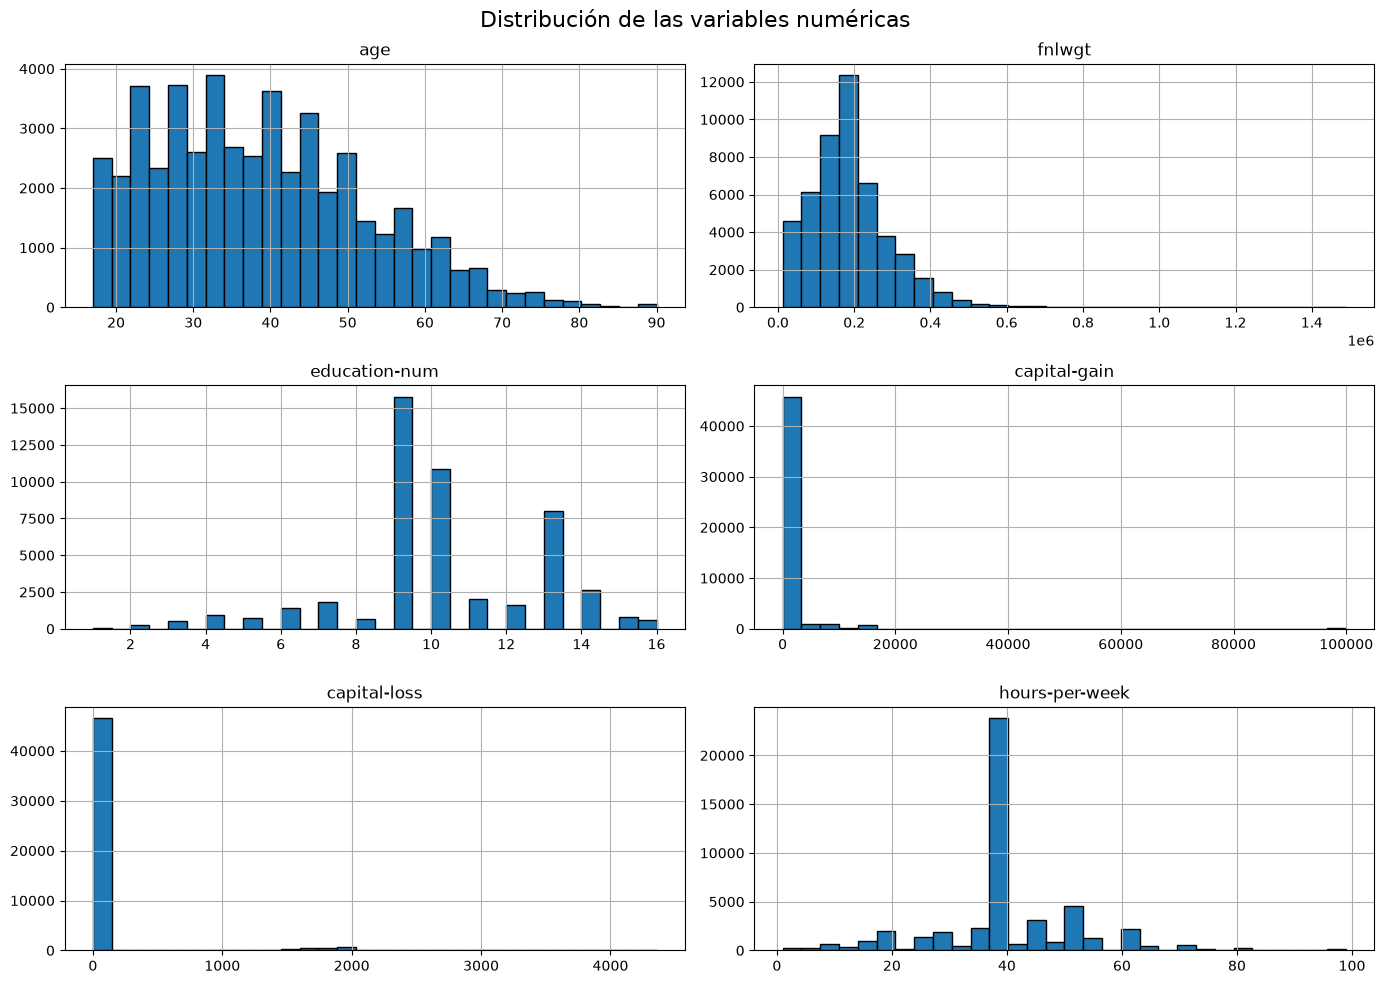

In [31]:
# Importar la biblioteca para crear gráficos
import matplotlib.pyplot as plt

# Crear un histograma para cada variable numérica
df_clean[numeric_columns].hist(
    bins=30,
    figsize=(14, 10),
    edgecolor="black"
)

# Agregar un título general y ajustar la distribución
plt.suptitle(
    "Distribución de las variables numéricas",
    fontsize=16
)
plt.tight_layout()
plt.show()

Se observa que en general las variables presentan asimetría positiva.

Capital gain: Asimetría positiva muy alta, con una gran cantidad de valores concentrados en 0.

Capital loss: Asimetría positiva también alta (aunque mucho menos que capital gain) y una gran concentración de valores en 0.

fnlwgt: Asimetría positiva más moderada, con una cola hacia la derecha.

Age: Asimetría positiva bastante leve.

Education num: Asimetría negativa leve.

Hours per week: Asimetría baja, presenta una gran concentración de valores en 40 horas.

En general, ninguna variable presenta una distribución normal según los histogramas y la mayoría presentan asimetría positiva, lo que significa que la mayoría de los valores son bajos o medios pero existen algunos valores muy altos que arrastran la distribución a la derecha.

### Decisión de limpieza

La asimetría no es un error en la calidad de los datos, solo muestra el comportamiento de la distribución de las variables. Aquí no se tiene que tomar alguna acción para limpiar los datos.

En posteriores etapas se puede analizar el uso de transformaciones o escalamiento para estos datos de ser necesario.

## Errores de unidad

Anteriormente ya se revisaron las variables numéricas y se determinó que age son años, hours per week en horas, education num es un código del nivel educativo, fnlwgt es un peso censal y capital gain y capital loss se encuentran en la misma escala.

No se detectaron variables con unidades mezcladas, conversiones incorrectas ni ningún tipo de error de unidad.

### Decisión de limpieza

Con base a lo anterior no fue necesario realizar alguna limpieza

## Leakage

Esto ocurre cuando el modelo recibe información que directa o indirectamente revela la respuesta que se quiere predecir.

En este dataset ninguna variable contiene la misma información o respuesta que la variable objetivo income. Las variables Capital gain y Capital loss probablemente tienen una fuerte relación con income pero solo son variables predictoras.

### Decisión de limpieza

Considerando todo esto no es necesario realizar ninguna limpieza de datos, solo se debe seguir trabajando para garantizar que no ocurra ningún data leakage, por esto el escalamiento, transformaciones, ect. se realizarán solo con los datos de entrenamiento con un pipeline reutilizable.

## Imbalance (Clases no balanceadas)

In [32]:
# Calcular la cantidad de registros de cada clase
class_count = df_clean["income"].value_counts()

# Calcular el porcentaje correspondiente a cada clase
class_percentage = (
    df_clean["income"].value_counts(normalize=True) * 100
).round(2)

# Unir cantidades y porcentajes en una tabla
class_distribution = pd.DataFrame({
    "Cantidad": class_count,
    "Porcentaje": class_percentage
})

class_distribution

,Cantidad,Porcentaje
income,,
<=50K,37109,76.06
>50K,11681,23.94


Claramente existe un problema de clases no balanceadas en este dataset, las personas con un ingreso menor o igual a 50K son la mayoría mientras que las personas con un ingreso mayor a 50K son la minoría. Esto quiere decir que no se puede confiar solo en la medida de accuracy para evaluar el modelo ya que podría predecir solo para la clase mayoritaria y aún así tener un "buen" desempeño.

### Decisión de limpieza

No se realizará ninguna acción de limpieza en este momento, durante el modelado se tendrá que volver a analizar esta situación y tomar las decisiones necesarias según el caso.

## Correlación excesiva

Considerando la existencia de asimetría positiva y de algunos valores extremos, se utilizará la correlación de Spearman (estudia las relaciones monotónicas, al aumentar una variable la otra se mueve siempre en una misma dirección, y es menos sensible a estas distribuciones).

In [33]:
# Calcular la correlación de Spearman entre variables numéricas
correlation_matrix = (
    df_clean[numeric_columns]
    .corr(method="spearman")
    .round(2)
)

# Mostrar la matriz con una escala de colores
correlation_matrix.style.background_gradient(
    cmap="coolwarm",
    vmin=-1,
    vmax=1
).format("{:.2f}")

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.00,-0.08,0.06,0.12,0.06,0.15
fnlwgt,-0.08,1.00,-0.03,-0.01,-0.00,-0.02
education-num,0.06,-0.03,1.00,0.12,0.08,0.16
capital-gain,0.12,-0.01,0.12,1.00,-0.07,0.09
capital-loss,0.06,-0.00,0.08,-0.07,1.00,0.06
hours-per-week,0.15,-0.02,0.16,0.09,0.06,1.00


No se observa ninguna correlación excesiva entre las variables numéricas, la más alta es la relación entre education num y hours per week pero solo fue de 0.16, que es relativamente bajo. Las otras relaciones son bastante cercanas a 0.

Las variables no contienen información muy parecida y ninguna presenta una correlación excesiva con otra.

### Decisión de limpieza

No se debe realizar ninguna acción de limpieza ya que no se detectó ninguna relación fuerte entre las variables numéricas como para que pueda ser posible eliminar alguna variable por repetir la misma información. En general, no se detectó multicolinealidad entre las variables numéricas.

Sin embargo, aquí es importante mencionar la existencia de las variables education y education num y la redundancia que genera, ambas variables presentan la misma información solo que una en formato numérico y otra en formato categórico. Esto se debe evaluar posteriormente para decidir cuál variable es más útil para el proyecto y cuál variable se puede eliminar.

## Anomalías estadísticas

In [34]:
# Calcular la posición porcentual de cada valor dentro de su variable
percentile_ranks = df_clean[numeric_columns].rank(
    pct=True,
    method="average"
)

# Marcar los valores ubicados en el 1 % inferior o superior
extreme_flags = (
    (percentile_ranks <= 0.01) |
    (percentile_ranks >= 0.99)
)

# Contar cuántas variables extremas presenta cada registro
extreme_count_per_row = extreme_flags.sum(axis=1)

# Mostrar la distribución de la cantidad de condiciones extremas por fila
extreme_count_per_row.value_counts().sort_index()

0    44262
1     4192
2      325
3       11
Name: count, dtype: int64

In [35]:
# Identificar las filas con tres o más variables extremas
most_unusual_mask = extreme_count_per_row >= 3

# Seleccionar los registros y conservar variables útiles para interpretarlos
most_unusual_records = df_clean.loc[
    most_unusual_mask,
    list(numeric_columns) + ["income", "sex", "race"]
].copy()

# Identificar cuáles variables fueron marcadas como extremas en cada fila
most_unusual_records["Variables_extremas"] = (
    extreme_flags.loc[most_unusual_mask]
    .apply(
        lambda row: ", ".join(row.index[row]),
        axis=1
    )
)

# Mostrar los registros más inusuales
display(most_unusual_records)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,sex,race,Variables_extremas
4018,72,118902,16,0,2392,6,>50K,Male,White,"education-num, capital-loss, hours-per-week"
4236,75,231741,16,4931,0,3,<=50K,Male,White,"age, education-num, hours-per-week"
6171,79,120707,16,20051,0,35,>50K,Male,White,"age, education-num, capital-gain"
12596,74,88638,16,0,3683,20,>50K,Female,White,"age, education-num, capital-loss"
14325,67,129188,16,20051,0,5,>50K,Male,White,"education-num, capital-gain, hours-per-week"
19852,77,84979,16,20051,0,40,>50K,Male,White,"age, education-num, capital-gain"
28159,79,62176,16,0,0,6,>50K,Male,White,"age, education-num, hours-per-week"
32974,75,26586,6,0,0,5,<=50K,Female,White,"age, fnlwgt, hours-per-week"
36266,77,267799,16,0,0,4,>50K,Male,White,"age, education-num, hours-per-week"
38824,62,191520,16,99999,0,80,>50K,Male,White,"education-num, capital-gain, hours-per-week"


Se identificó que la mayoría de las filas no presenta valores extremos, 4196 presentan 1 valor extremo, 325 2 valores extremos y 11 filas tienen 3 valores extremos.

En la tabla anterior se pueden observar las filas con las mayores anomalías, en general presentan edades altas, education num alto, capital gain o capital loss altas y hours per week poco frecuentes (tanto altas como bajas). Ninguno de estos eran valores imposibles.

Algo interesante a considerar es que la mayoría de estas anomalías estadísticas pertenecen a la clase minoritaria.

### Decisión de limpieza

Considerando lo anterior se tienen 2 opciones.

Eliminar las anomalías: Se podrían eliminar estos registros, pero los valores son posibles y en su mayoría pertenecen a la clase minoritaria.

Conservar las anomalías: Se pueden conservar estas anomalías ya que siguen siendo valores posibles y así no se afectaría más la proporción de la clase minoritaria.

Se consideró que la mejor decisión era conservar esas anomalías.


## Verificación final

In [36]:
# Contar símbolos "?" que permanezcan en las columnas de texto
remaining_question_marks = (
    df_clean
    .select_dtypes(include=["object", "string"])
    .apply(
        lambda column: (
            column.astype("string")
            .str.strip()
            .eq("?")
            .sum()
        )
    )
    .sum()
)

# Obtener las clases finales de la variable objetivo
final_target_classes = set(
    df_clean["income"].dropna().unique()
)

expected_target_classes = {"<=50K", ">50K"}

# Crear el resumen de las verificaciones finales
final_validation = pd.DataFrame({
    "Verificación": [
        "Cantidad de filas",
        "Cantidad de columnas",
        "Valores faltantes",
        "Símbolos ?",
        "Filas duplicadas",
        "Clases de income"
    ],
    "Resultado": [
        len(df_clean),
        df_clean.shape[1],
        int(df_clean.isna().sum().sum()),
        int(remaining_question_marks),
        int(df_clean.duplicated().sum()),
        ", ".join(sorted(final_target_classes))
    ],
    "Esperado": [
        48790,
        15,
        0,
        0,
        0,
        "<=50K, >50K"
    ],
    "Cumple": [
        len(df_clean) == 48790,
        df_clean.shape[1] == 15,
        df_clean.isna().sum().sum() == 0,
        remaining_question_marks == 0,
        df_clean.duplicated().sum() == 0,
        final_target_classes == expected_target_classes
    ]
})

final_validation

,Verificación,Resultado,Esperado,Cumple
0,Cantidad de filas,48790,48790,True
1,Cantidad de columnas,15,15,True
2,Valores faltantes,0,0,True
3,Símbolos ?,0,0,True
4,Filas duplicadas,0,0,True
5,Clases de income,"<=50K, >50K","<=50K, >50K",True
